# Merge And Complements

This notebook is the third step in the operator sequence. The first notebook introduced unary decompositions. The second notebook introduced composition and additive unions. Here we focus on three operators that transform an existing decomposition into a contrasting or aggregated view: `merge`, `complement`, and `edge_complement`.

Previous: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)  
Next: [04 Filters And Selection](./example_abstract_graph_operators_04_filters_and_selection.ipynb)

## What you will see

We will focus on three ideas:

1. `merge()` collapses many mapped subgraphs into one aggregate mapped subgraph.
2. `complement()` keeps the nodes outside the current mapped subgraph.
3. `edge_complement()` keeps the base-graph edges that are missing from the current mapped subgraph.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


# label_mode options:
# - "graph_hash": hash the mapped image subgraph structure
# - "operator_hash": hash the operator/user-name metadata

def draw(graph, decomposition_function, *, nbits=11, label_mode="graph_hash", size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    )
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## A larger graph for spine-based complements

This notebook uses a larger stitched graph so removing the `spine(radius=0)` path leaves a visible outside structure for `complement()` and a richer missing-edge pattern for `edge_complement()`.

Graph with 14 nodes and 17 edges


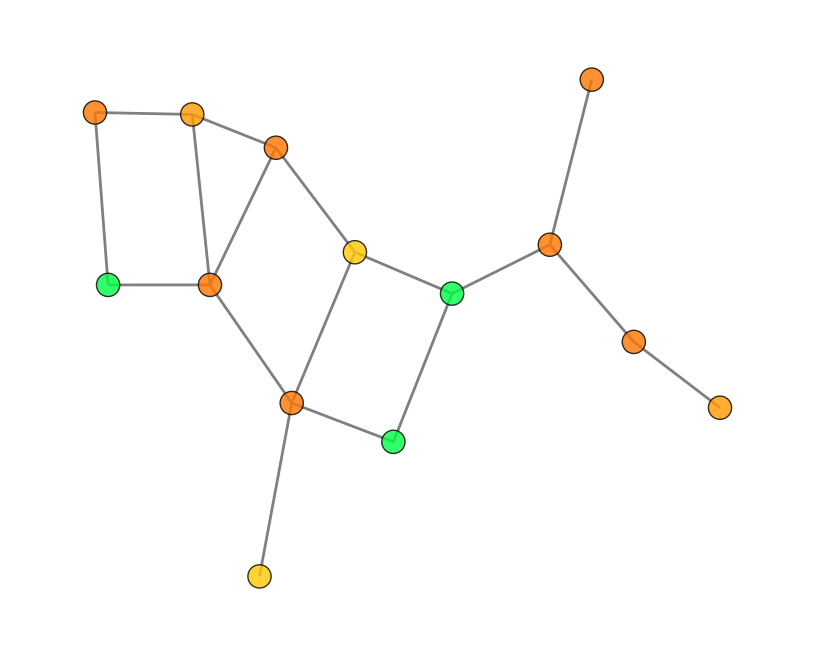

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'C'}),
    (1, {'label': 'C'}),
    (2, {'label': 'O'}),
    (3, {'label': 'N'}),
    (4, {'label': 'C'}),
    (5, {'label': 'S'}),
    (6, {'label': 'C'}),
    (7, {'label': 'O'}),
    (8, {'label': 'C'}),
    (9, {'label': 'N'}),
    (10, {'label': 'C'}),
    (11, {'label': 'O'}),
    (12, {'label': 'C'}),
    (13, {'label': 'S'}),
])
graph.add_edges_from([
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6),
    (2, 7), (7, 8), (8, 9),
    (4, 10), (10, 11),
    (1, 12), (12, 13),
    (3, 8), (5, 10), (6, 11),
    (8, 10),
])

print(graph)
display_graph(graph)


## `merge()` after a mixed decomposition

A useful pattern is to build several mapped subgraphs and then collapse them into one combined interpretation node. Here we start with cycles and trees, connect overlapping mapped subgraphs, and then merge them.

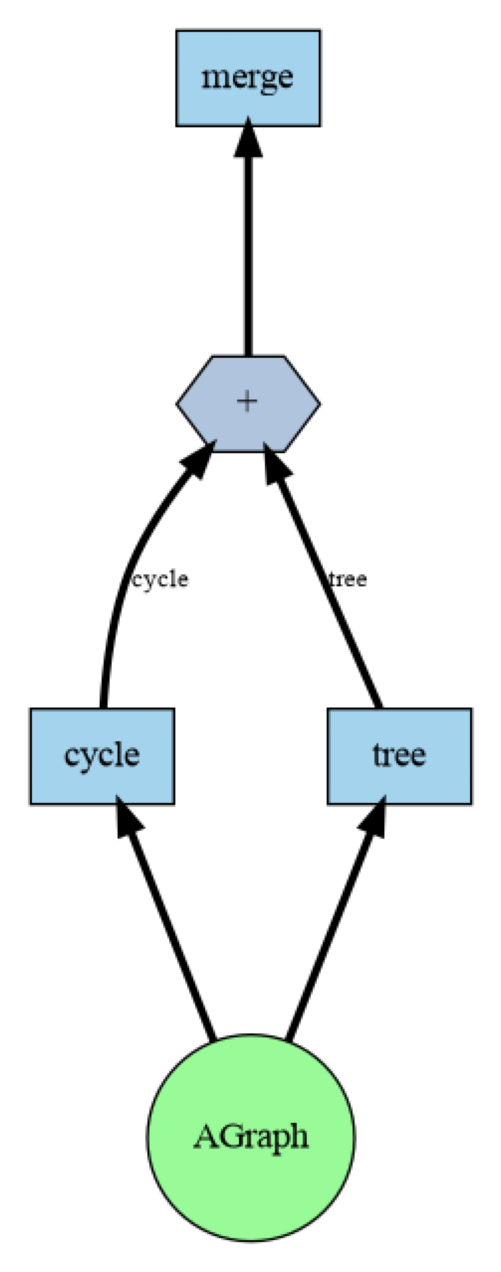

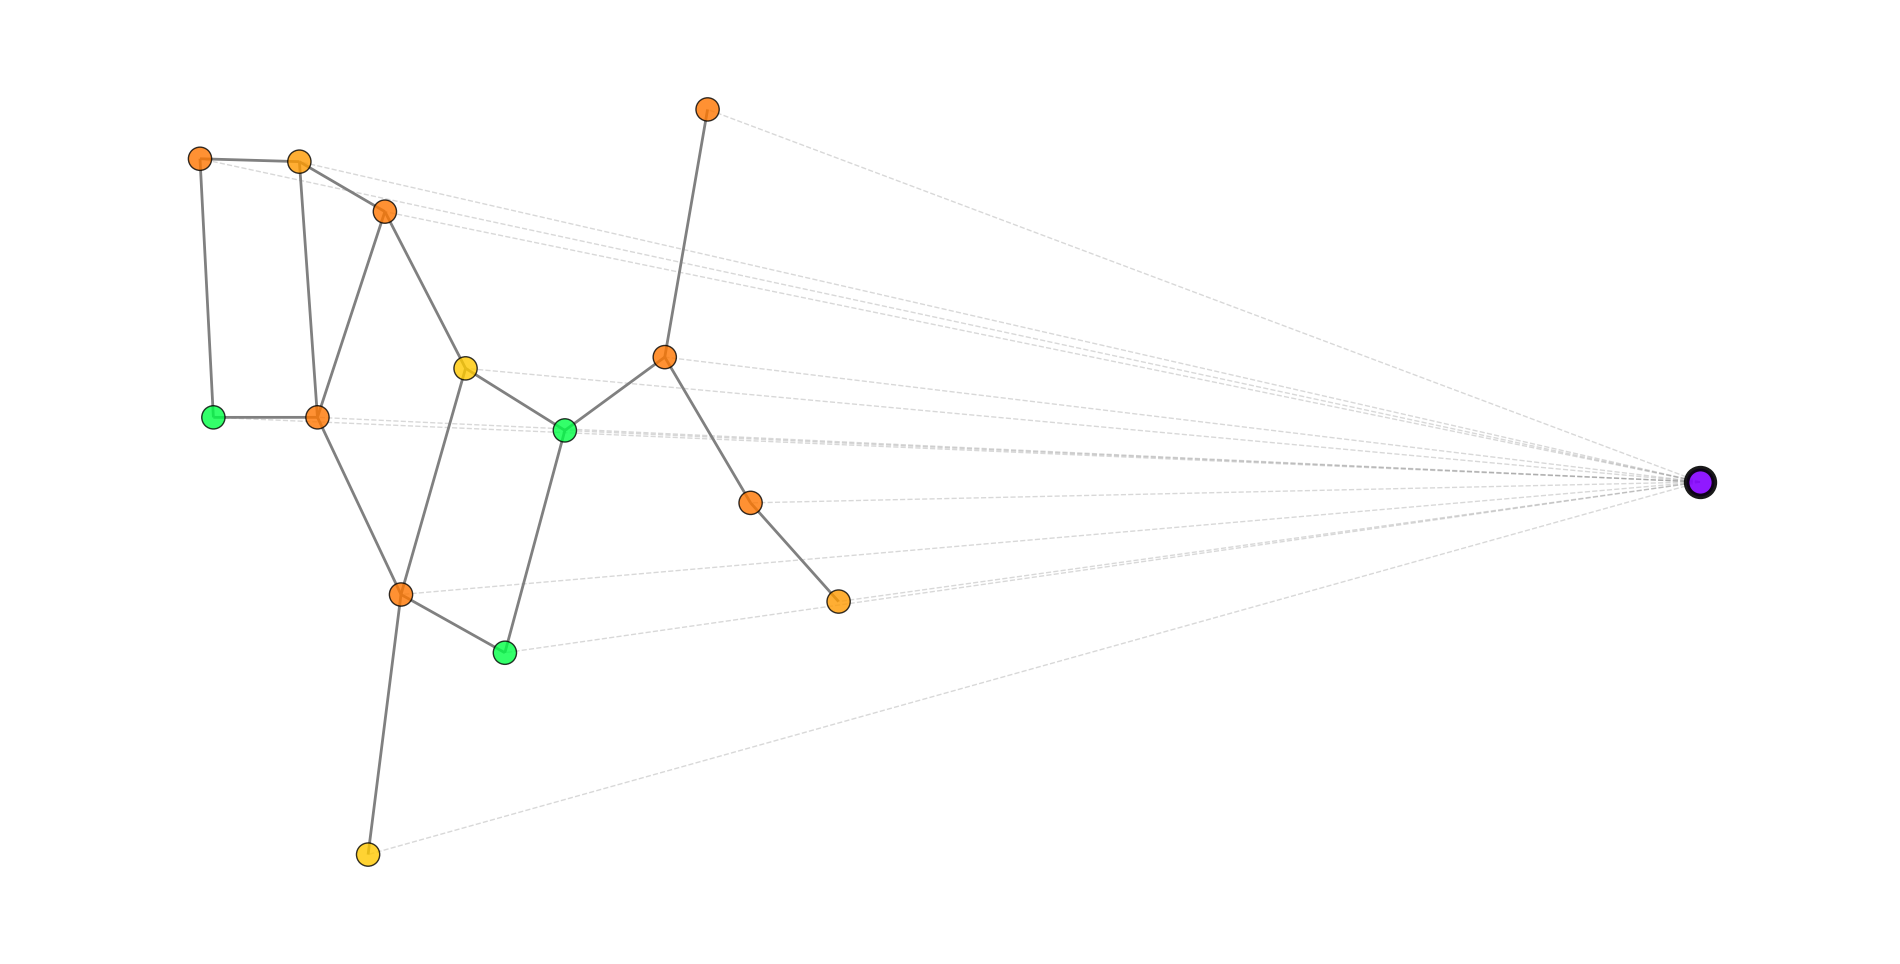

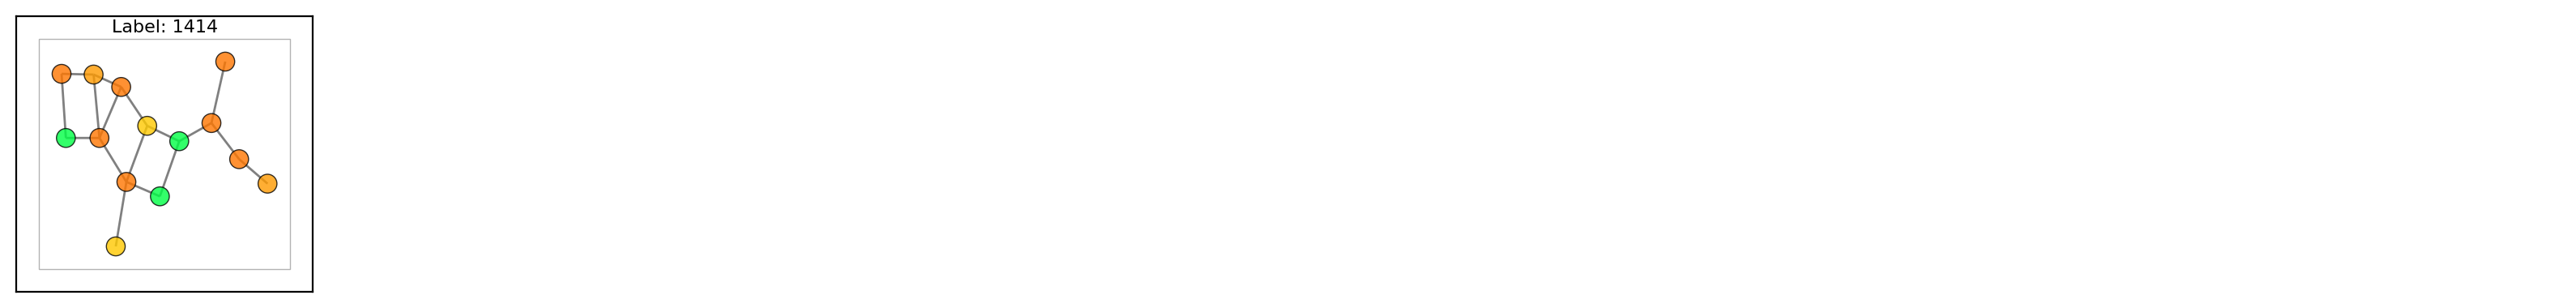

In [5]:
df = compose(merge(), add(cycle(), tree()))
merged_cycle_tree_ag = draw(graph, df)

## `merge(use_edges=True)` keeps the union of edges

The edge-aware merge is helpful when the decomposition emits overlapping edge motifs and you want one aggregate edge-induced subgraph.

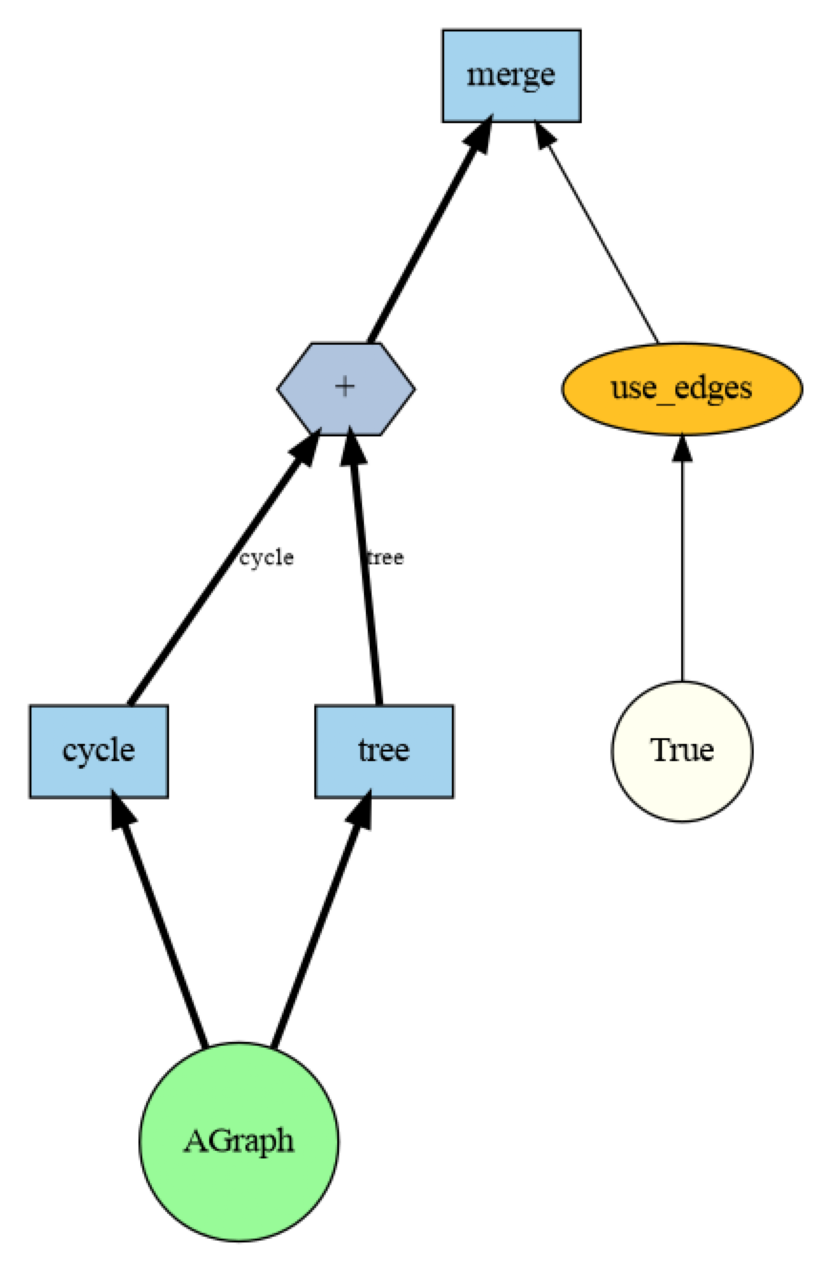

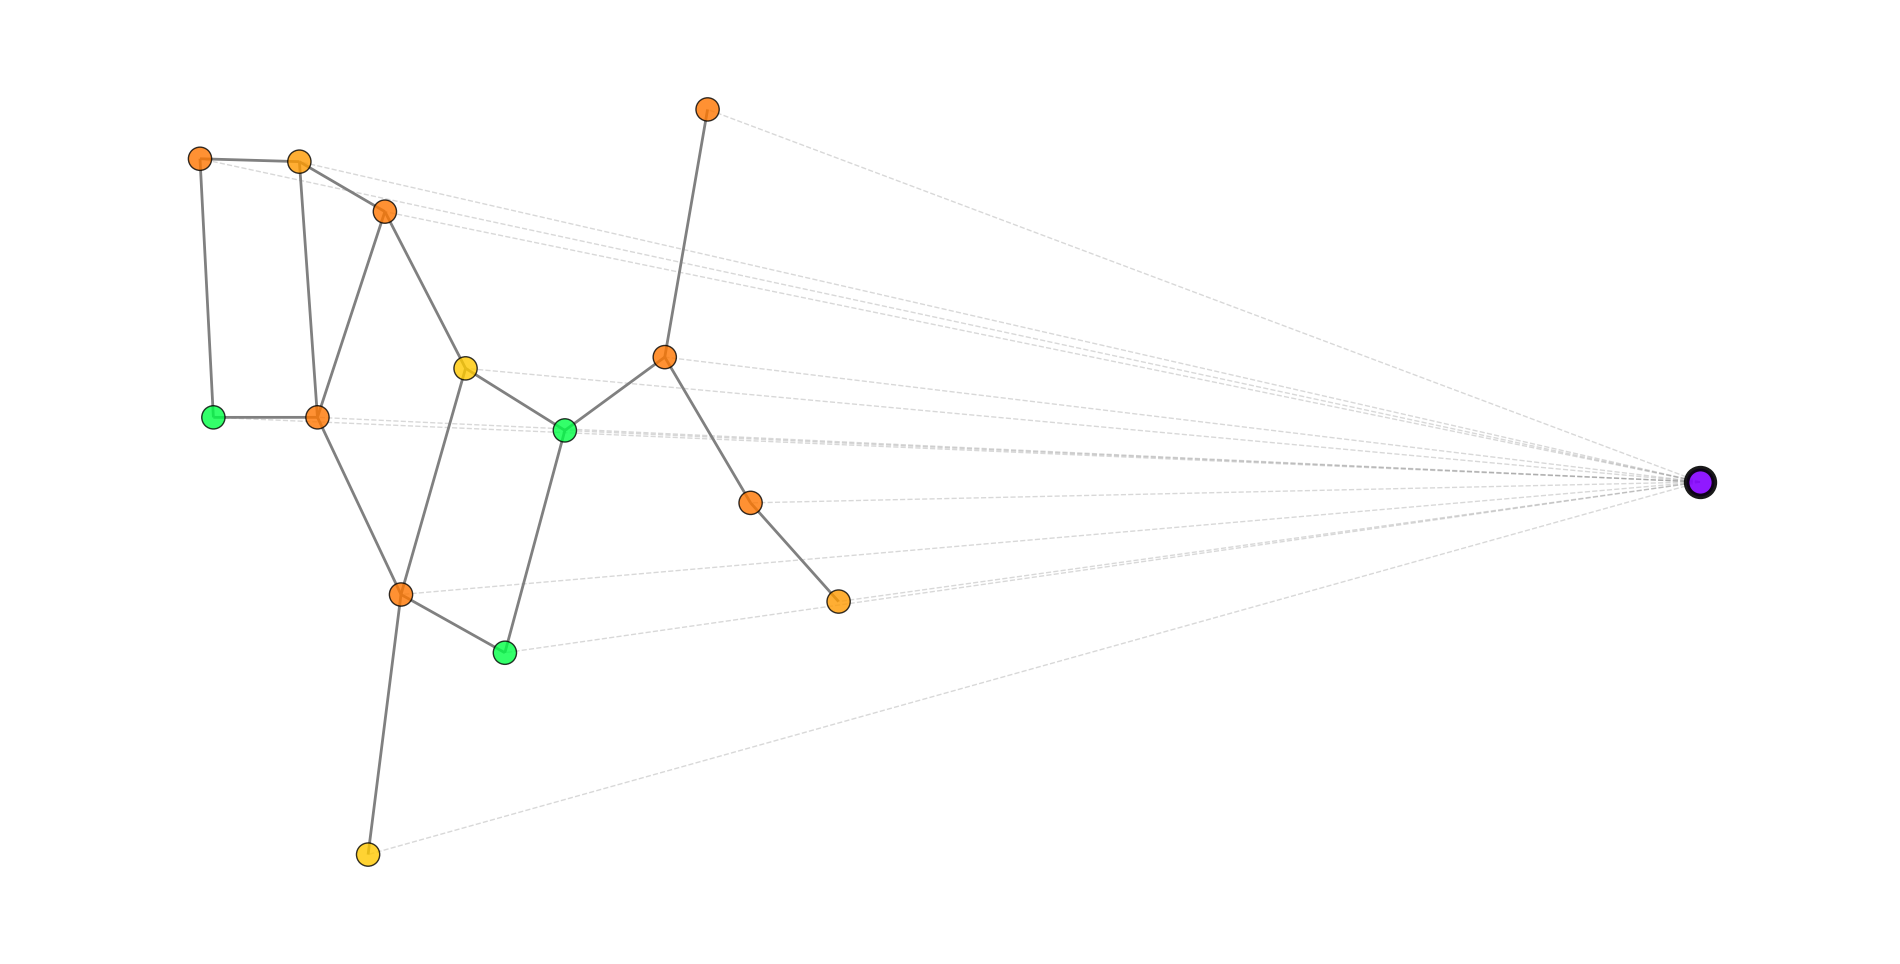

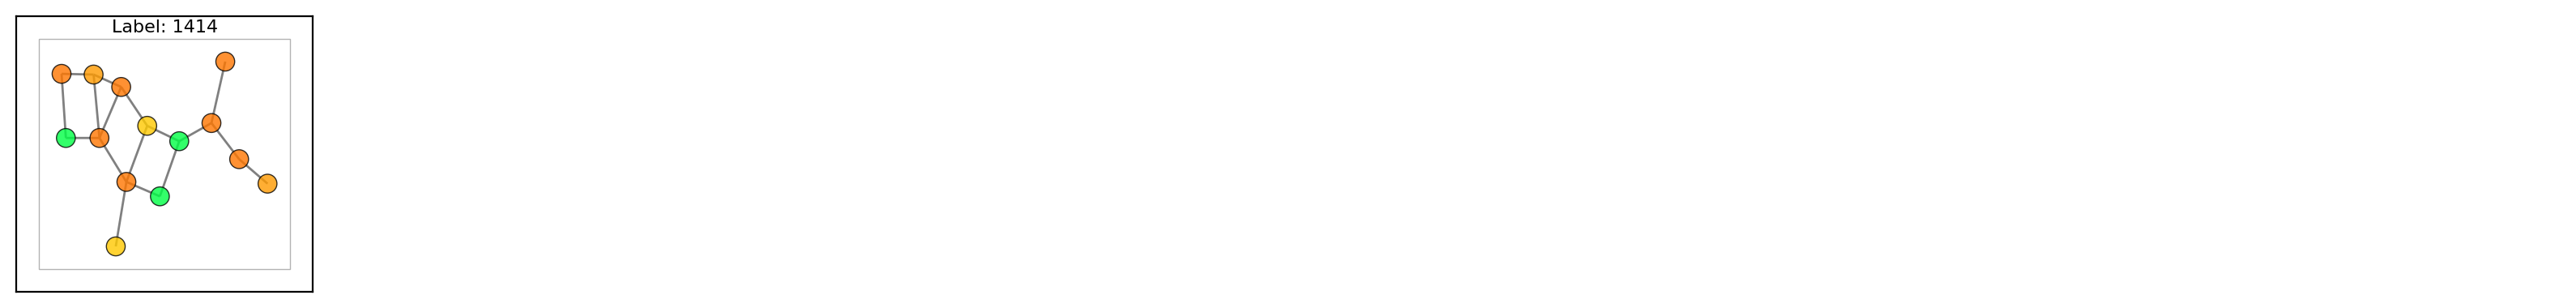

In [6]:
df = compose(merge(use_edges=True), add(cycle(), tree()))
merged_edges_ag = draw(graph, df)

## `complement()` around a spine decomposition

Start from `spine(radius=0)` to isolate a central induced subgraph, then use `complement()` to view everything in the original graph that lies outside that spine-based selection.

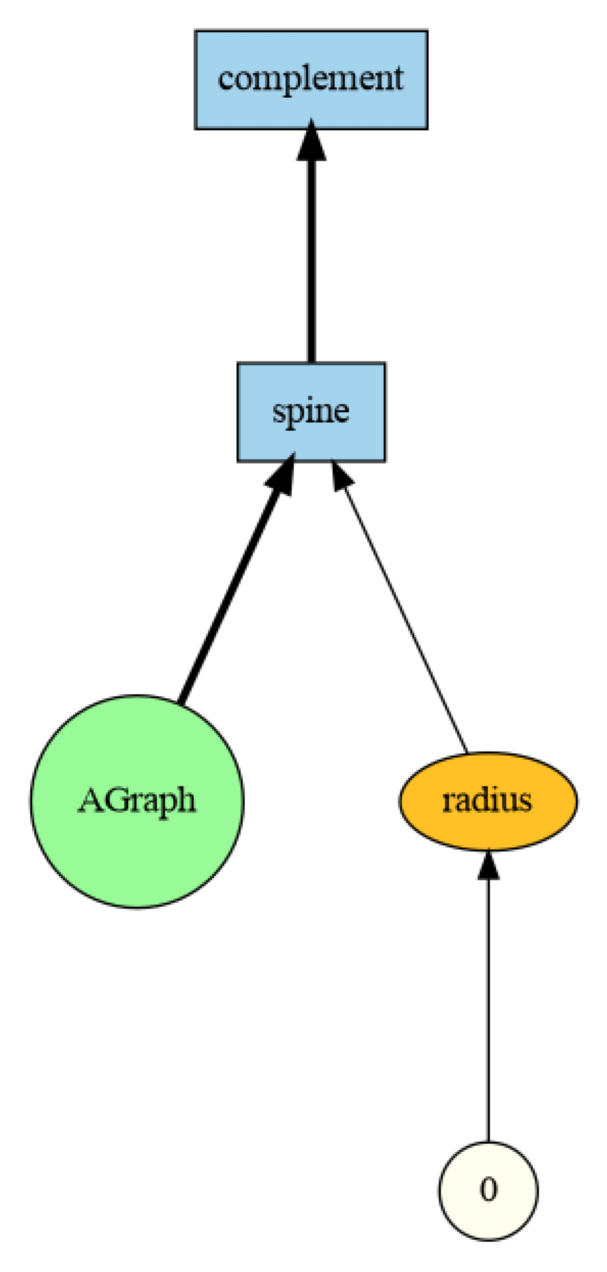

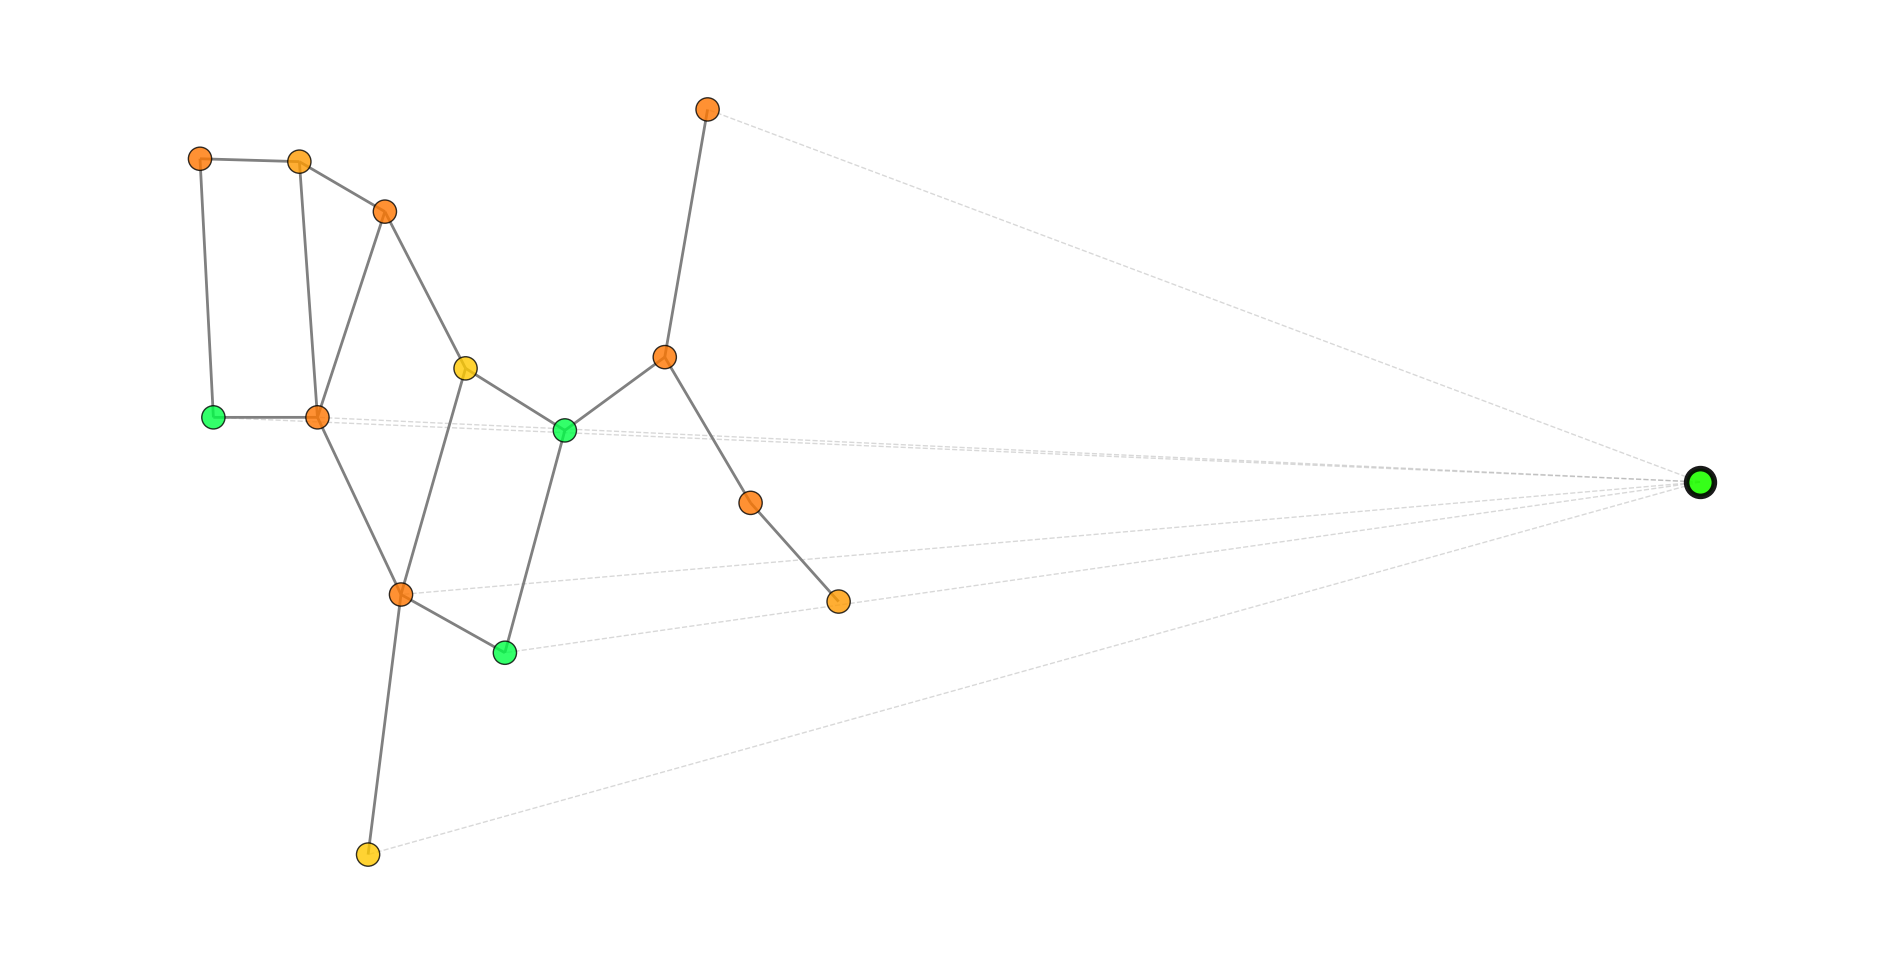

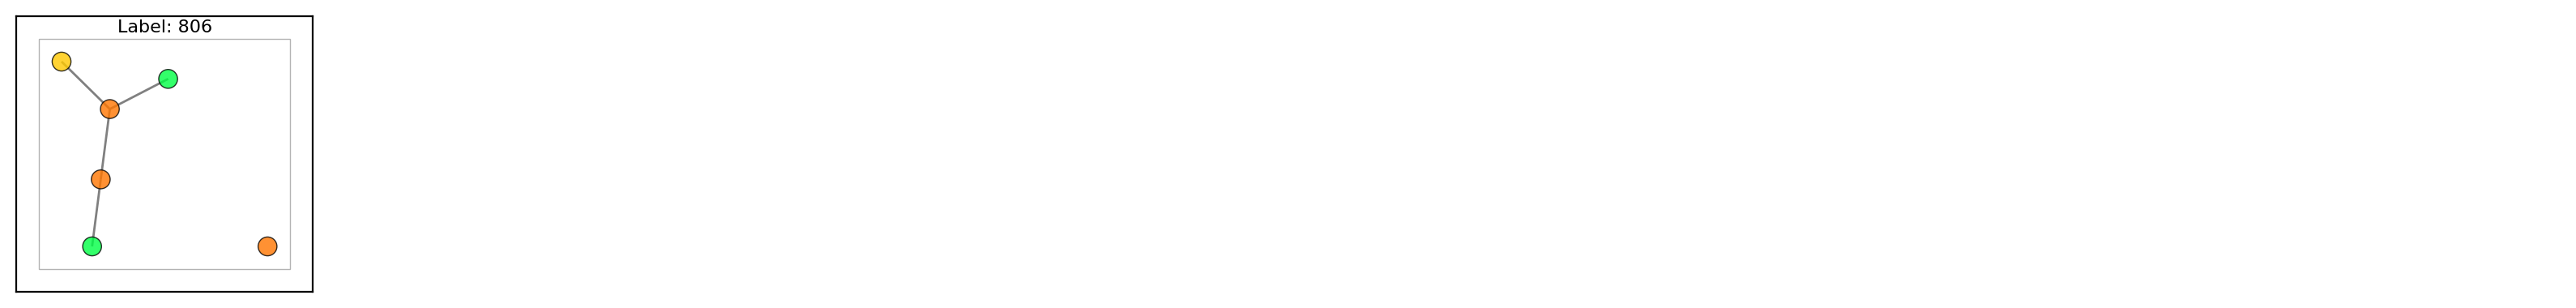

In [7]:
df = compose(complement(), spine(radius=0))
complement_spine_ag = draw(graph, df)

## `edge_complement()` on the same spine

Use the same `spine(radius=0)` decomposition, but keep the original nodes and swap the internal edges for the missing ones with `edge_complement()`.

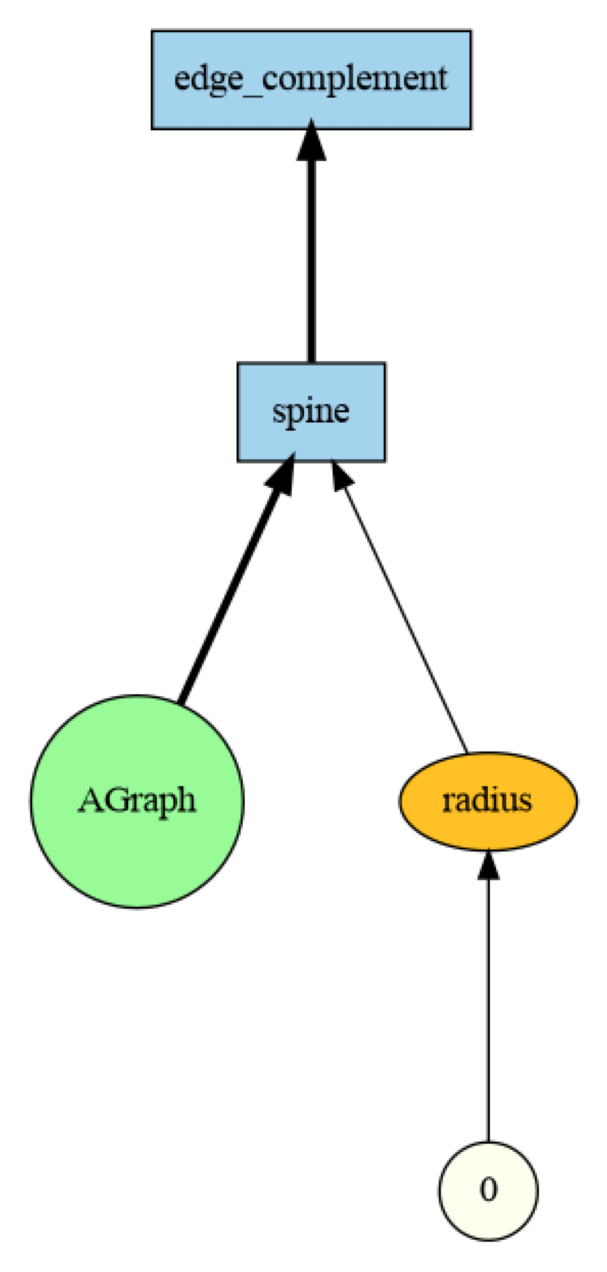

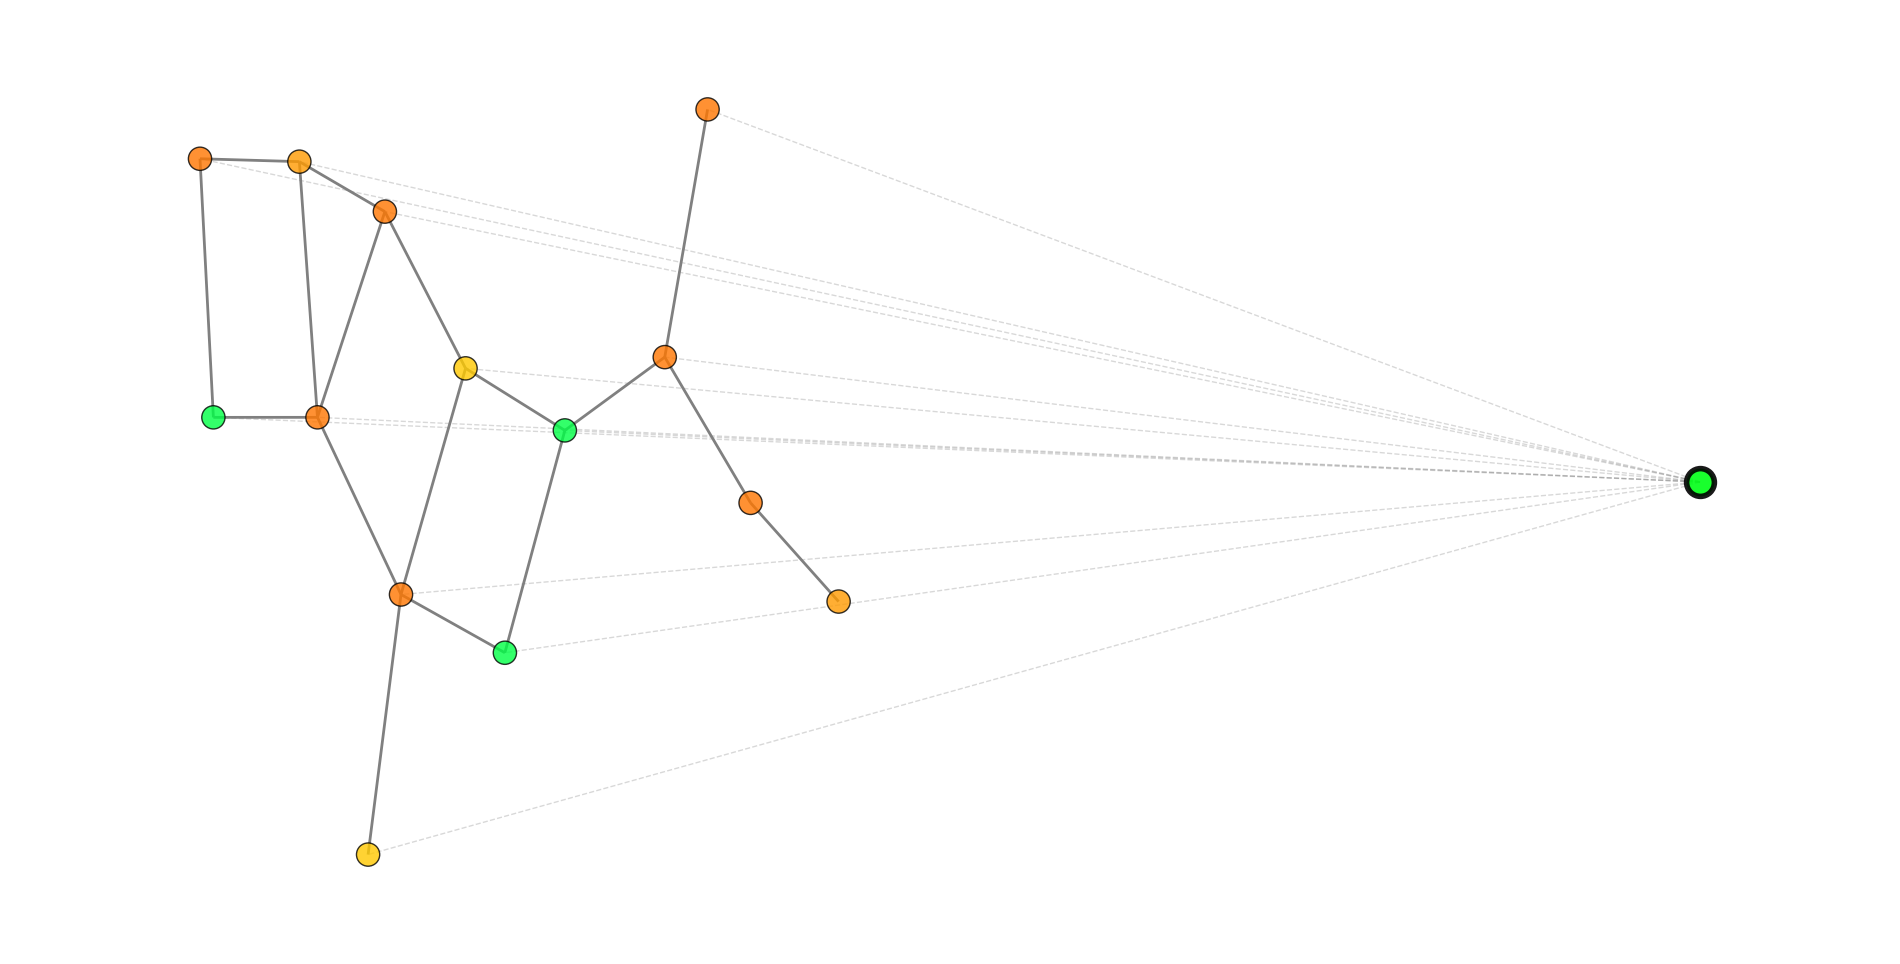

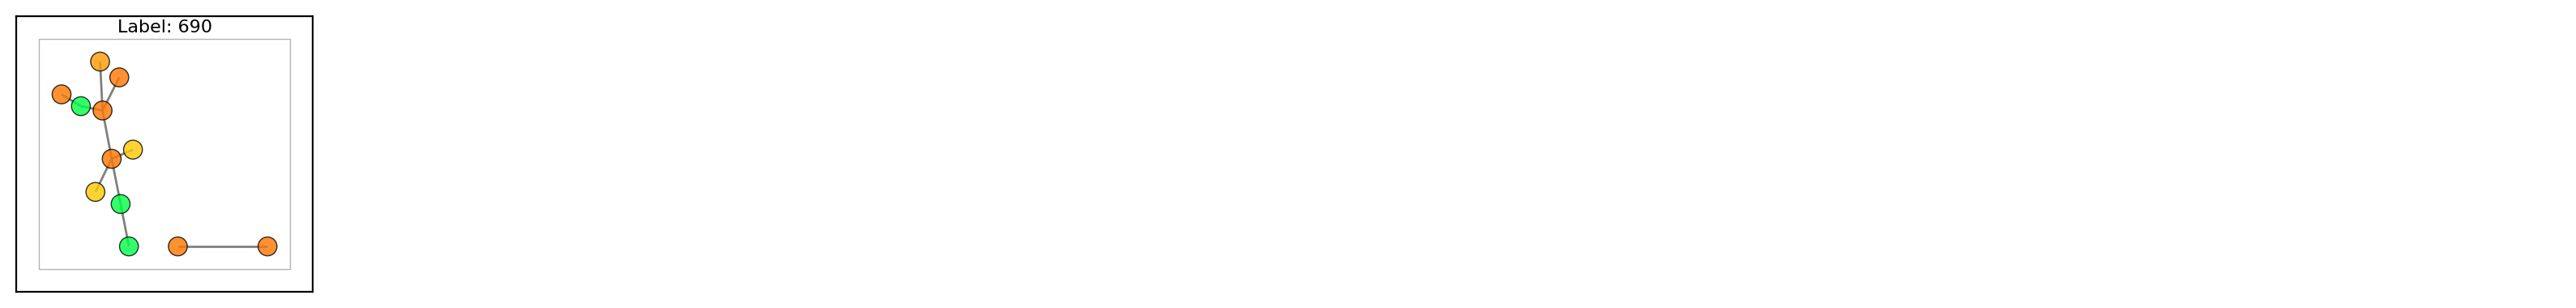

In [8]:
df = compose(edge_complement(), spine(radius=0))
edge_complement_spine_ag = draw(graph, df)

## Spine-driven partitioning with complement-side glue

This pattern first keeps one `spine(radius=0)` backbone. It then takes the `edge_complement()` of that spine, splits that complement into `connected_component()` pieces, and extracts edge-complement glue. Finally, `add(...)` puts the backbone and those complement-side pieces back together into one partition-like decomposition of the graph.

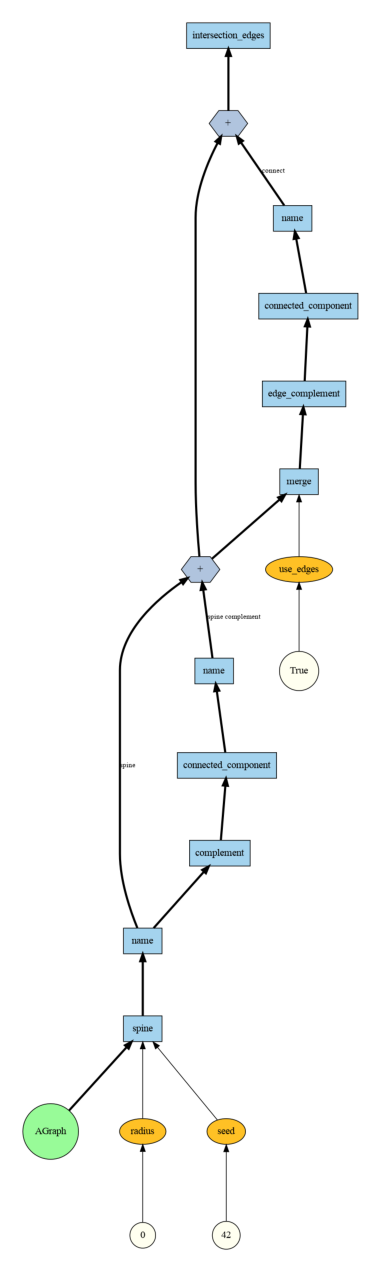

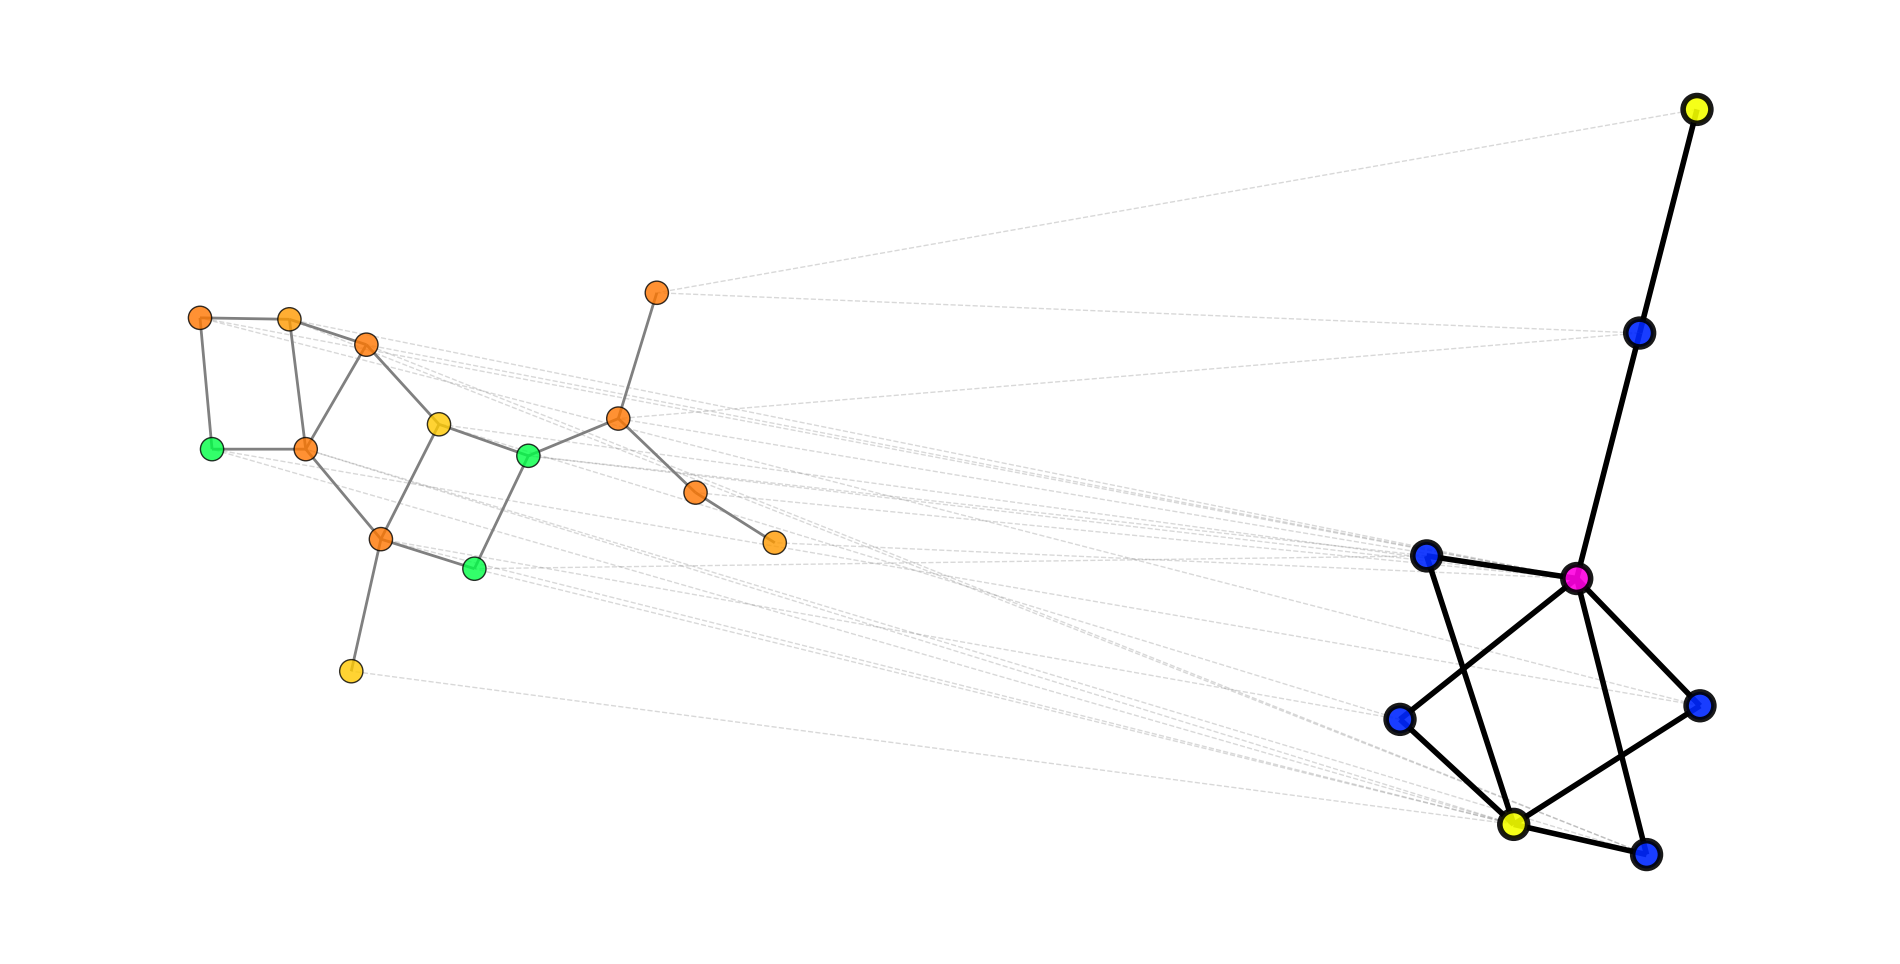

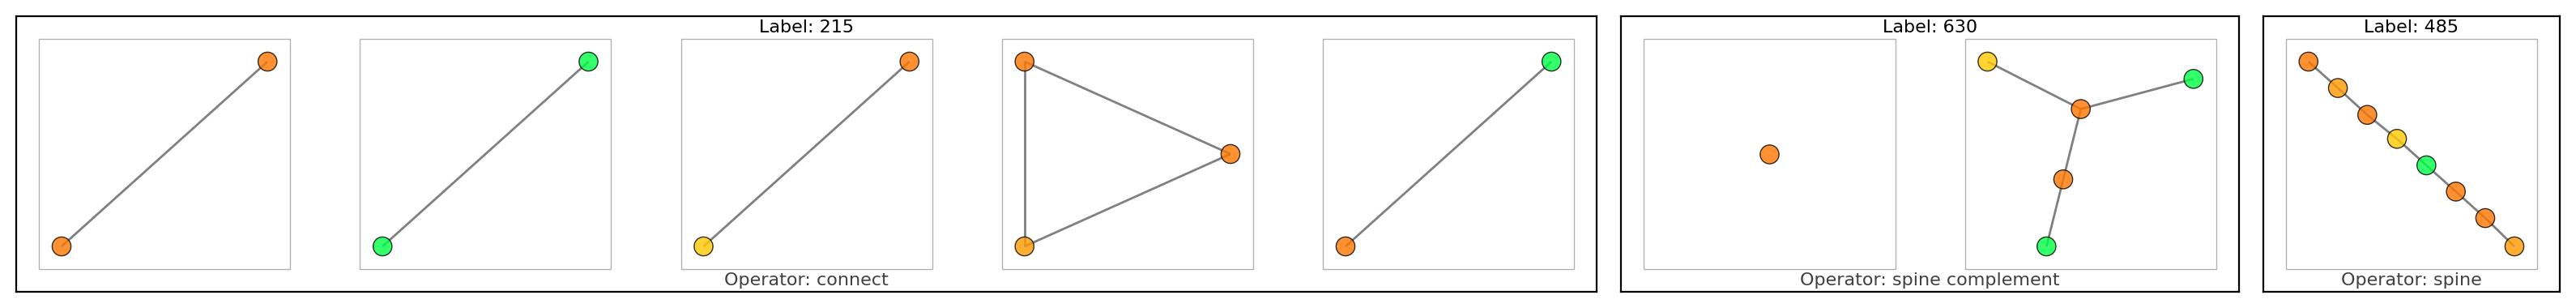

In [9]:
sp0 = compose(name('spine'), spine(radius=0, seed=42))
sp1 = compose(name('spine complement'), connected_component(), complement(), sp0)
core_df = add(sp0, sp1)
connector_df = compose(name('connect'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
df = compose(intersection_edges(), add(core_df, connector_df))

_ = draw(graph, df,label_mode="operator_hash")

## Summary

`merge()` aggregates a decomposition into one interpretation node. `complement()` flips a node-set view into its outside context. `edge_complement()` flips an edge-set view into the missing-edge context. Combined with `spine()` and `connected_component()`, they can also define a recursive partitioning workflow that peels away a backbone and subdivides the remaining edge structure.

Previous: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)  
Next: [04 Filters And Selection](./example_abstract_graph_operators_04_filters_and_selection.ipynb)